# 今日数学笔记：一维高斯分布（正态分布）

## 一、 核心概念与公式：概率密度函数 (PDF)
连续变量不能算“某一个精确点的概率”（概率为0），只能算“区间内曲线下的面积”（积分）。
* **PDF 公式 (必须眼熟)**：
  $$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$
* **大白话**：这是一个完美的“钟形曲线”。公式里那一堆常数（如 $\sqrt{2\pi}$）只是为了强行让整条曲线下的总面积等于 1。

## 二、 决定曲线形状的两个灵魂参数
1. **期望 (Expectation) $\mu$**：
   * **物理意义**：决定了钟形曲线的**中心位置**（最高点在哪里）。
   * **作用**：改变 $\mu$，曲线在X轴上左右平移。
2. **方差 (Variance) $\sigma^2$ (以及标准差 $\sigma$)**：
   * **物理意义**：决定了数据的**离散程度**（曲线的胖瘦）。
   * **作用**：$\sigma$ 越大，数据越分散，曲线越矮胖；$\sigma$ 越小，数据越集中，曲线越瘦高。

## 三、 为什么它在深度学习里这么重要？
### 1. 中心极限定理 (Central Limit Theorem)
* **神级结论**：现实世界中，不管个体数据原本是什么极其诡异的分布，只要把大量相互独立的随机变量**相加**，它们的最终和，**一定会无限逼近高斯分布**。
* **直觉**：高斯分布是自然界数据分布的“最终归宿”。

### 2. 在神经网络中的两大应用
* **权重初始化**：一开始我们不希望网络有任何偏见，所以用 $\mu=0$、$\sigma$ 很小（如 $0.01$）的高斯分布来随机生成初始权重矩阵。
* **均方误差 (MSE) 的底层假设**：当我们用 MSE 计算 Loss 时，数学上其实等价于做了一个隐藏假设——“模型预测值与真实值之间的误差（噪声），服从均值为 0 的高斯分布”。

In [ ]:
# LeNet
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer. __class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


loss 0.506, train acc 0.806, test acc 0.788
12655.3 examples/sec on cpu


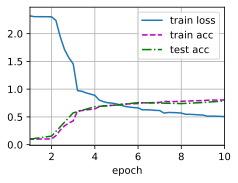

In [3]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)
lr, num_epochs = 0.9, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

In [4]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import time

# 自动选择计算设备 (支持你的 MacBook mps 加速)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"当前使用的计算设备: {device}")

# ==========================================
# 填空挑战 1：用 nn.Sequential 拼装现代版 LeNet
# 提示：用 3x3 卷积(padding=1) 和 2x2 池化
# ==========================================
class ModernLeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # TODO 1: 第一层 (卷积 + 激活 + 池化)
            # 提示: 1通道进 -> 64通道出
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # TODO 2: 第二层 (卷积 + 激活 + 池化)
            # 提示: 64通道进 -> 128通道出
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # TODO 3: 展平层
            nn.Flatten(),
            
            # TODO 4: 全连接层 (漏斗式降维: ? -> 1024 -> 256 -> 10)
            # 警告: 这里的第一个输入维度需要你自己在草稿纸上算一下！(输入图是 28x28)
            nn.Linear(6272, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 10)
            
        )
        
    def forward(self, x):
        return self.net(x)

# 实例化模型并推送到设备
model = ModernLeNet().to(device)

# ==========================================
# 数据准备、损失函数与优化器 (已为你写好)
# ==========================================
trans = transforms.ToTensor()
train_data = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=trans, download=True)
test_data = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=trans, download=True)

train_iter = DataLoader(train_data, batch_size=256, shuffle=True)
test_iter = DataLoader(test_data, batch_size=256, shuffle=False)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# ==========================================
# 填空挑战 2：纯净版训练循环
# ==========================================
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    start_time = time.time()
    
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        
        # TODO 5: 默写经典的 PyTorch 训练五步流！
        # 1. 前向传播
        y_hat = model(X)
        # 2. 计算 Loss
        loss = loss_fn(y_hat, y)
        # 3. 梯度清零
        optimizer.zero_grad()
        # 4. 反向传播
        loss.backward()
        # 5. 更新参数
        optimizer.step()
        
        
        
        
        
        total_loss += loss.item()
        
    # 测试集评估
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_iter:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            correct += (y_hat.argmax(1) == y).type(torch.float).sum().item()
            total += y.size(0)
            
    print(f"Epoch {epoch+1:2d} | "
          f"Loss: {total_loss/len(train_iter):.4f} | "
          f"Test Acc: {correct/total:.4f} | "
          f"Time: {time.time()-start_time:.1f}s")

当前使用的计算设备: mps


100.0%
100.0%
100.0%
100.0%


Epoch  1 | Loss: 1.0721 | Test Acc: 0.7386 | Time: 10.1s
Epoch  2 | Loss: 0.5720 | Test Acc: 0.6816 | Time: 7.4s
Epoch  3 | Loss: 0.4631 | Test Acc: 0.8138 | Time: 7.4s
Epoch  4 | Loss: 0.4029 | Test Acc: 0.8182 | Time: 7.4s
Epoch  5 | Loss: 0.3645 | Test Acc: 0.8634 | Time: 7.4s
Epoch  6 | Loss: 0.3390 | Test Acc: 0.8249 | Time: 7.5s
Epoch  7 | Loss: 0.3175 | Test Acc: 0.8751 | Time: 7.6s
Epoch  8 | Loss: 0.2992 | Test Acc: 0.8556 | Time: 7.4s
Epoch  9 | Loss: 0.2851 | Test Acc: 0.8658 | Time: 7.4s
Epoch 10 | Loss: 0.2721 | Test Acc: 0.8876 | Time: 7.6s
